In [19]:
import torch
from transformers import GPT2LMHeadModel, GPT2TokenizerFast
import numpy as np
import pandas as pd
from collections import defaultdict

class EightValuePrimingCalculator:
    def __init__(self, model_name="gpt2"):
        self.model = GPT2LMHeadModel.from_pretrained(model_name)
        self.tokenizer = GPT2TokenizerFast.from_pretrained(model_name)
        self.model.eval()
        if self.tokenizer.pad_token is None:
            self.tokenizer.pad_token = self.tokenizer.eos_token

    def _get_probability(self, prime, target):
        combined = f"{prime}. {target}"
        inputs = self.tokenizer.encode(combined, return_tensors="pt")
        prime_inputs = self.tokenizer.encode(f"{prime}. ", return_tensors="pt")
        prime_length = prime_inputs.shape[1]
        
        with torch.no_grad():
            outputs = self.model(inputs)
            logits = outputs.logits
            target_logits = logits[0, prime_length-1:-1]
            target_labels = inputs[0, prime_length:]
            
            log_probs = []
            for logit, label in zip(target_logits, target_labels):
                log_softmax = torch.log_softmax(logit, dim=-1)
                log_probs.append(log_softmax[label].item())
            
            log_prob = sum(log_probs)
            raw_prob = np.exp(log_prob)
            
            return log_prob, raw_prob

    def process_tsv_data(self, tsv_file):
        df = pd.read_csv(tsv_file, sep='\t')
        
        data = {
            'of_prime_s_target': [],   # of -> s
            's_prime_s_target': [],    # s -> s目 
            'of_prime_of_target': [],  # of -> of
            's_prime_of_target': []    # s -> of
        }
        
        # Michaelov metric
        pairs = defaultdict(list)
        
        for _, row in df.iterrows():
            prime_type = row['PrimeType']
            target_type = row['TargetType']
            prime_sentence = row['PrimeSentence']
            target_sentence = row['TargetSentence']
            set_id = row['Set']
            condition = row['ExtraCondition']
            
            key = f"{set_id}_{condition}"
            pairs[key].append({
                'prime_type': prime_type,
                'target_type': target_type,
                'prime_sentence': prime_sentence,
                'target_sentence': target_sentence
            })
            
            # Sinclair metric
            if 'of-genitive' in prime_type and 's-genitive' in target_type:
                data['of_prime_s_target'].append((prime_sentence, target_sentence))
            elif 's-genitive' in prime_type and 's-genitive' in target_type:
                data['s_prime_s_target'].append((prime_sentence, target_sentence))
            elif 'of-genitive' in prime_type and 'of-genitive' in target_type:
                data['of_prime_of_target'].append((prime_sentence, target_sentence))
            elif 's-genitive' in prime_type and 'of-genitive' in target_type:
                data['s_prime_of_target'].append((prime_sentence, target_sentence))
        
        return data, pairs

    def calculate_sinclair_effects(self, data):
        results = {}
        
        for category, pairs_list in data.items():
            log_probs = []
            for prime, target in pairs_list:
                log_prob, _ = self._get_probability(prime, target)
                log_probs.append(log_prob)
            
            avg_log_prob = np.mean(log_probs) if log_probs else 0
            results[f'Sinclair_{category}'] = round(avg_log_prob, 4)
        
        return results

    def calculate_michaelov_effects(self, pairs):
        results = {
            'of_prime_s_target': [],
            's_prime_s_target': [],
            'of_prime_of_target': [],
            's_prime_of_target': []
        }
        
        for key, items in pairs.items():
            if len(items) == 4: 
                s_s = next((item for item in items if 's-genitive' in item['prime_type'] and 's-genitive' in item['target_type']), None)
                s_of = next((item for item in items if 's-genitive' in item['prime_type'] and 'of-genitive' in item['target_type']), None)
                of_s = next((item for item in items if 'of-genitive' in item['prime_type'] and 's-genitive' in item['target_type']), None)
                of_of = next((item for item in items if 'of-genitive' in item['prime_type'] and 'of-genitive' in item['target_type']), None)
                
                if all([s_s, s_of, of_s, of_of]):
                    _, prob_s_s = self._get_probability(s_s['prime_sentence'], s_s['target_sentence'])
                    _, prob_s_of = self._get_probability(s_of['prime_sentence'], s_of['target_sentence'])
                    _, prob_of_s = self._get_probability(of_s['prime_sentence'], of_s['target_sentence'])
                    _, prob_of_of = self._get_probability(of_of['prime_sentence'], of_of['target_sentence'])
                    
                    total_s = prob_s_s + prob_of_s
                    norm_s_s = prob_s_s / total_s if total_s > 0 else 0.5
                    norm_of_s = prob_of_s / total_s if total_s > 0 else 0.5
                    
                    total_of = prob_s_of + prob_of_of
                    norm_s_of = prob_s_of / total_of if total_of > 0 else 0.5
                    norm_of_of = prob_of_of / total_of if total_of > 0 else 0.5

                    
                    results['s_prime_s_target'].append(norm_s_s)
                    results['of_prime_s_target'].append(norm_of_s)
                    results['of_prime_of_target'].append(norm_of_of)
                    results['s_prime_of_target'].append(norm_s_of)
        
    
        final_results = {}
        for category, values in results.items():
            avg_value = np.mean(values) if values else 0
            final_results[f'Michaelov_{category}'] = round(avg_value, 4)
        
        return final_results

    def calculate_all_effects(self, tsv_file):
        data, pairs = self.process_tsv_data(tsv_file)
        
        sinclair_results = self.calculate_sinclair_effects(data)
        michaelov_results = self.calculate_michaelov_effects(pairs)
        
        return {**sinclair_results, **michaelov_results}

def process_file(tsv_file_path):
    calc = EightValuePrimingCalculator()
    results = calc.calculate_all_effects(tsv_file_path)
    
    print(f"Sinclair_of_prime_s_target: {results['Sinclair_of_prime_s_target']}")
    print(f"Sinclair_s_prime_s_target: {results['Sinclair_s_prime_s_target']}")
    print(f"Sinclair_of_prime_of_target: {results['Sinclair_of_prime_of_target']}")
    print(f"Sinclair_s_prime_of_target: {results['Sinclair_s_prime_of_target']}")
    print(f"Michaelov_of_prime_s_target: {results['Michaelov_of_prime_s_target']}")
    print(f"Michaelov_s_prime_s_target: {results['Michaelov_s_prime_s_target']}")
    print(f"Michaelov_of_prime_of_target: {results['Michaelov_of_prime_of_target']}")
    print(f"Michaelov_s_prime_of_target: {results['Michaelov_s_prime_of_target']}")

if __name__ == "__main__":
    tsv_file_path = "bernolet_2013.tsv" 
    process_file(tsv_file_path)

Sinclair_of_prime_s_target: -21.714
Sinclair_s_prime_s_target: -18.276
Sinclair_of_prime_of_target: -19.7183
Sinclair_s_prime_of_target: -25.8258
Michaelov_of_prime_s_target: 0.1249
Michaelov_s_prime_s_target: 0.8751
Michaelov_of_prime_of_target: 0.9665
Michaelov_s_prime_of_target: 0.0335


In [21]:
import torch
from transformers import GPT2LMHeadModel, GPT2TokenizerFast
import numpy as np
import pandas as pd
from collections import defaultdict

class PODOPrimingCalculator:
    def __init__(self, model_name="gpt2"):
        self.model = GPT2LMHeadModel.from_pretrained(model_name)
        self.tokenizer = GPT2TokenizerFast.from_pretrained(model_name)
        self.model.eval()
        if self.tokenizer.pad_token is None:
            self.tokenizer.pad_token = self.tokenizer.eos_token

    def _get_probability(self, prime, target):
        combined = f"{prime}. {target}"
        inputs = self.tokenizer.encode(combined, return_tensors="pt")
        prime_inputs = self.tokenizer.encode(f"{prime}. ", return_tensors="pt")
        prime_length = prime_inputs.shape[1]
        
        with torch.no_grad():
            outputs = self.model(inputs)
            logits = outputs.logits
            target_logits = logits[0, prime_length-1:-1]
            target_labels = inputs[0, prime_length:]
            
            log_probs = []
            for logit, label in zip(target_logits, target_labels):
                log_softmax = torch.log_softmax(logit, dim=-1)
                log_probs.append(log_softmax[label].item())
            
            log_prob = sum(log_probs)
            raw_prob = np.exp(log_prob)
            
            return log_prob, raw_prob

    def process_tsv_data(self, tsv_file):
        df = pd.read_csv(tsv_file, sep='\t')
        
        data = {
            'PO_prime_DO_target': [],   # PO -> DO
            'DO_prime_DO_target': [],   # DO -> DO  
            'PO_prime_PO_target': [],   # PO -> PO
            'DO_prime_PO_target': []    # DO -> PO
        }
        
        # Michaelov
        pairs = defaultdict(list)
        
        for _, row in df.iterrows():
            prime_type = row['PrimeType']
            target_type = row['TargetType']
            prime_sentence = row['PrimeSentence']
            target_sentence = row['TargetSentence']
            set_id = row['Set']
            condition = row['ExtraCondition']
            
            key = f"{set_id}_{condition}"
            pairs[key].append({
                'prime_type': prime_type,
                'target_type': target_type,
                'prime_sentence': prime_sentence,
                'target_sentence': target_sentence
            })
            
            # Sinclair
            if 'PO_Prime' in prime_type and 'DO_Target' in target_type:
                data['PO_prime_DO_target'].append((prime_sentence, target_sentence))
            elif 'DO_Prime' in prime_type and 'DO_Target' in target_type:
                data['DO_prime_DO_target'].append((prime_sentence, target_sentence))
            elif 'PO_Prime' in prime_type and 'PO_Target' in target_type:
                data['PO_prime_PO_target'].append((prime_sentence, target_sentence))
            elif 'DO_Prime' in prime_type and 'PO_Target' in target_type:
                data['DO_prime_PO_target'].append((prime_sentence, target_sentence))
        
        return data, pairs

    def calculate_sinclair_effects(self, data):
        results = {}
        
        for category, pairs_list in data.items():
            log_probs = []
            for prime, target in pairs_list:
                log_prob, _ = self._get_probability(prime, target)
                log_probs.append(log_prob)
            
            avg_log_prob = np.mean(log_probs) if log_probs else 0
            results[f'Sinclair_{category}'] = round(avg_log_prob, 4)
        
        return results

    def calculate_michaelov_effects(self, pairs):
        results = {
            'PO_prime_DO_target': [],
            'DO_prime_DO_target': [],
            'PO_prime_PO_target': [],
            'DO_prime_PO_target': []
        }
        
        for key, items in pairs.items():
            if len(items) == 4: 
                do_do = next((item for item in items if 'DO_Prime' in item['prime_type'] and 'DO_Target' in item['target_type']), None)
                do_po = next((item for item in items if 'DO_Prime' in item['prime_type'] and 'PO_Target' in item['target_type']), None)
                po_do = next((item for item in items if 'PO_Prime' in item['prime_type'] and 'DO_Target' in item['target_type']), None)
                po_po = next((item for item in items if 'PO_Prime' in item['prime_type'] and 'PO_Target' in item['target_type']), None)
                
                if all([do_do, do_po, po_do, po_po]):
                    _, prob_do_do = self._get_probability(do_do['prime_sentence'], do_do['target_sentence'])
                    _, prob_do_po = self._get_probability(do_po['prime_sentence'], do_po['target_sentence'])
                    _, prob_po_do = self._get_probability(po_do['prime_sentence'], po_do['target_sentence'])
                    _, prob_po_po = self._get_probability(po_po['prime_sentence'], po_po['target_sentence'])

                    total_do = prob_do_do + prob_po_do
                    norm_do_do = prob_do_do / total_do if total_do > 0 else 0.5
                    norm_po_do = prob_po_do / total_do if total_do > 0 else 0.5
                    
                    total_po = prob_do_po + prob_po_po
                    norm_do_po = prob_do_po / total_po if total_po > 0 else 0.5
                    norm_po_po = prob_po_po / total_po if total_po > 0 else 0.5
                    
                    results['DO_prime_DO_target'].append(norm_do_do)
                    results['PO_prime_DO_target'].append(norm_po_do)
                    results['PO_prime_PO_target'].append(norm_po_po)
                    results['DO_prime_PO_target'].append(norm_do_po)
        
        final_results = {}
        for category, values in results.items():
            avg_value = np.mean(values) if values else 0
            final_results[f'Michaelov_{category}'] = round(avg_value, 4)
        
        return final_results

    def calculate_all_effects(self, tsv_file):
        data, pairs = self.process_tsv_data(tsv_file)
        
        sinclair_results = self.calculate_sinclair_effects(data)
        michaelov_results = self.calculate_michaelov_effects(pairs)
        
        return {**sinclair_results, **michaelov_results}

def process_file(tsv_file_path):
    calc = PODOPrimingCalculator()
    results = calc.calculate_all_effects(tsv_file_path)
    
    print(f"Sinclair_PO_prime_DO_target: {results['Sinclair_PO_prime_DO_target']}")
    print(f"Sinclair_DO_prime_DO_target: {results['Sinclair_DO_prime_DO_target']}")
    print(f"Sinclair_PO_prime_PO_target: {results['Sinclair_PO_prime_PO_target']}")
    print(f"Sinclair_DO_prime_PO_target: {results['Sinclair_DO_prime_PO_target']}")
    print(f"Michaelov_PO_prime_DO_target: {results['Michaelov_PO_prime_DO_target']}")
    print(f"Michaelov_DO_prime_DO_target: {results['Michaelov_DO_prime_DO_target']}")
    print(f"Michaelov_PO_prime_PO_target: {results['Michaelov_PO_prime_PO_target']}")
    print(f"Michaelov_DO_prime_PO_target: {results['Michaelov_DO_prime_PO_target']}")

if __name__ == "__main__":
    tsv_file_path = "schoonbaert_2007.tsv"
    process_file(tsv_file_path)

Sinclair_PO_prime_DO_target: -32.5624
Sinclair_DO_prime_DO_target: -29.9608
Sinclair_PO_prime_PO_target: -31.2436
Sinclair_DO_prime_PO_target: -34.1659
Michaelov_PO_prime_DO_target: 0.1563
Michaelov_DO_prime_DO_target: 0.8437
Michaelov_PO_prime_PO_target: 0.8487
Michaelov_DO_prime_PO_target: 0.1513


In [1]:
import torch
from transformers import GPT2LMHeadModel, GPT2TokenizerFast
import numpy as np
import pandas as pd
from collections import defaultdict

class ActivePassivePrimingCalculator:
    def __init__(self, model_name="gpt2"):
        self.model = GPT2LMHeadModel.from_pretrained(model_name)
        self.tokenizer = GPT2TokenizerFast.from_pretrained(model_name)
        self.model.eval()
        if self.tokenizer.pad_token is None:
            self.tokenizer.pad_token = self.tokenizer.eos_token

    def _get_probability(self, prime, target):
        combined = f"{prime}. {target}"
        inputs = self.tokenizer.encode(combined, return_tensors="pt")
        prime_inputs = self.tokenizer.encode(f"{prime}. ", return_tensors="pt")
        prime_length = prime_inputs.shape[1]
        
        with torch.no_grad():
            outputs = self.model(inputs)
            logits = outputs.logits
            target_logits = logits[0, prime_length-1:-1]
            target_labels = inputs[0, prime_length:]
            
            log_probs = []
            for logit, label in zip(target_logits, target_labels):
                log_softmax = torch.log_softmax(logit, dim=-1)
                log_probs.append(log_softmax[label].item())
            
            log_prob = sum(log_probs)
            raw_prob = np.exp(log_prob)
            
            return log_prob, raw_prob

    def process_tsv_data(self, tsv_file):
        df = pd.read_csv(tsv_file, sep='\t')
        
        data = {
            'Passive_prime_Active_target': [],   # pas -> act
            'Active_prime_Active_target': [],    # act -> pas
            'Passive_prime_Passive_target': [],  # pas -> pas
            'Active_prime_Passive_target': []    # act -> pas
        }
        
        # Michaelov
        pairs = defaultdict(list)
        
        for _, row in df.iterrows():
            prime_type = row['PrimeType']
            target_type = row['TargetType']
            prime_sentence = row['PrimeSentence']
            target_sentence = row['TargetSentence']
            set_id = row['Set']
            
            key = f"{set_id}"
            pairs[key].append({
                'prime_type': prime_type,
                'target_type': target_type,
                'prime_sentence': prime_sentence,
                'target_sentence': target_sentence
            })
            
            # Sinclair
            if 'Passive_Prime' in prime_type and 'Active_Target' in target_type:
                data['Passive_prime_Active_target'].append((prime_sentence, target_sentence))
            elif 'Active_Prime' in prime_type and 'Active_Target' in target_type:
                data['Active_prime_Active_target'].append((prime_sentence, target_sentence))
            elif 'Passive_Prime' in prime_type and 'Passive_Target' in target_type:
                data['Passive_prime_Passive_target'].append((prime_sentence, target_sentence))
            elif 'Active_Prime' in prime_type and 'Passive_Target' in target_type:
                data['Active_prime_Passive_target'].append((prime_sentence, target_sentence))
        
        return data, pairs

    def calculate_sinclair_effects(self, data):
        results = {}
        
        for category, pairs_list in data.items():
            log_probs = []
            for prime, target in pairs_list:
                log_prob, _ = self._get_probability(prime, target)
                log_probs.append(log_prob)
            
            avg_log_prob = np.mean(log_probs) if log_probs else 0
            results[f'Sinclair_{category}'] = round(avg_log_prob, 4)
        
        return results

    def calculate_michaelov_effects(self, pairs):
        results = {
            'Passive_prime_Active_target': [],
            'Active_prime_Active_target': [],
            'Passive_prime_Passive_target': [],
            'Active_prime_Passive_target': []
        }
        
        for key, items in pairs.items():
            if len(items) == 4: 
                active_active = next((item for item in items if 'Active_Prime' in item['prime_type'] and 'Active_Target' in item['target_type']), None)
                active_passive = next((item for item in items if 'Active_Prime' in item['prime_type'] and 'Passive_Target' in item['target_type']), None)
                passive_active = next((item for item in items if 'Passive_Prime' in item['prime_type'] and 'Active_Target' in item['target_type']), None)
                passive_passive = next((item for item in items if 'Passive_Prime' in item['prime_type'] and 'Passive_Target' in item['target_type']), None)
                
                if all([active_active, active_passive, passive_active, passive_passive]):
                    _, prob_active_active = self._get_probability(active_active['prime_sentence'], active_active['target_sentence'])
                    _, prob_active_passive = self._get_probability(active_passive['prime_sentence'], active_passive['target_sentence'])
                    _, prob_passive_active = self._get_probability(passive_active['prime_sentence'], passive_active['target_sentence'])
                    _, prob_passive_passive = self._get_probability(passive_passive['prime_sentence'], passive_passive['target_sentence'])
                    
       
                    total_active = prob_active_active + prob_passive_active
                    norm_active_active = prob_active_active / total_active if total_active > 0 else 0.5
                    norm_passive_active = prob_passive_active / total_active if total_active > 0 else 0.5
                    
                    total_passive = prob_active_passive + prob_passive_passive
                    norm_active_passive = prob_active_passive / total_passive if total_passive > 0 else 0.5
                    norm_passive_passive = prob_passive_passive / total_passive if total_passive > 0 else 0.5
                    
                    results['Active_prime_Active_target'].append(norm_active_active)
                    results['Passive_prime_Active_target'].append(norm_passive_active)
                    results['Passive_prime_Passive_target'].append(norm_passive_passive)
                    results['Active_prime_Passive_target'].append(norm_active_passive)
        
        final_results = {}
        for category, values in results.items():
            avg_value = np.mean(values) if values else 0
            final_results[f'Michaelov_{category}'] = round(avg_value, 4)
        
        return final_results

    def calculate_all_effects(self, tsv_file):
        data, pairs = self.process_tsv_data(tsv_file)
        
        sinclair_results = self.calculate_sinclair_effects(data)
        michaelov_results = self.calculate_michaelov_effects(pairs)
        
        return {**sinclair_results, **michaelov_results}

def process_file(tsv_file_path):
    calc = ActivePassivePrimingCalculator()
    results = calc.calculate_all_effects(tsv_file_path)
    
    print(f"Sinclair_Passive_prime_Active_target: {results['Sinclair_Passive_prime_Active_target']}")
    print(f"Sinclair_Active_prime_Active_target: {results['Sinclair_Active_prime_Active_target']}")
    print(f"Sinclair_Passive_prime_Passive_target: {results['Sinclair_Passive_prime_Passive_target']}")
    print(f"Sinclair_Active_prime_Passive_target: {results['Sinclair_Active_prime_Passive_target']}")
    print(f"Michaelov_Passive_prime_Active_target: {results['Michaelov_Passive_prime_Active_target']}")
    print(f"Michaelov_Active_prime_Active_target: {results['Michaelov_Active_prime_Active_target']}")
    print(f"Michaelov_Passive_prime_Passive_target: {results['Michaelov_Passive_prime_Passive_target']}")
    print(f"Michaelov_Active_prime_Passive_target: {results['Michaelov_Active_prime_Passive_target']}")

if __name__ == "__main__":
    tsv_file_path = "kotzochampou_2022.tsv"
    process_file(tsv_file_path)

Sinclair_Passive_prime_Active_target: -25.7008
Sinclair_Active_prime_Active_target: -24.6697
Sinclair_Passive_prime_Passive_target: -25.6352
Sinclair_Active_prime_Passive_target: -29.8798
Michaelov_Passive_prime_Active_target: 0.2964
Michaelov_Active_prime_Active_target: 0.7036
Michaelov_Passive_prime_Passive_target: 0.9455
Michaelov_Active_prime_Passive_target: 0.0545


In [8]:
import spacy
import spacy.cli
from nltk.tree import Tree, ParentedTree
from collections import defaultdict
from math import exp, sqrt
import pandas as pd
from typing import Set, List, Dict, Tuple

class UniversalPrimingCalculator:
    def __init__(self, gamma: float = 1.0):

        self.gamma = gamma
        try:
            self.nlp = spacy.load('en_core_web_sm')
        except OSError:
            print("Downloading spaCy model...")
            spacy.cli.download('en_core_web_sm')
            self.nlp = spacy.load('en_core_web_sm')
    
    def get_constituents(self, tree: ParentedTree) -> Set[str]:

        constituents = set()
        for subtree in tree.subtrees():
            constituent_str = ' '.join(str(subtree).split())
            constituents.add(constituent_str)
        return constituents
    
    def get_production_rules(self, tree: ParentedTree) -> List[str]:

        productions = []
        for subtree in tree.subtrees():
            if len(subtree) > 0: 
                rule = f"{subtree.label()} -> {' '.join(n.label() if isinstance(n, Tree) else n for n in subtree)}"
                productions.append(rule)
        return productions
    
    def parse_sentence(self, sentence: str) -> ParentedTree:

        def build_tree(token):
            node_label = f"{token.pos_}_{token.dep_}"
            
            children = list(token.children)
            
            if not children:
                return ParentedTree(node_label, [token.text])
            
            # Non-leaf node: recursively process all children
            child_trees = [build_tree(child) for child in children]
            
            if token.pos_ not in ['DET', 'ADP', 'PART', 'CCONJ', 'SCONJ']:
                child_trees.append(ParentedTree(f"WORD_{token.pos_}", [token.text]))
            
            return ParentedTree(node_label, child_trees)
        
        doc = self.nlp(sentence)
        
        root_token = next(token for token in doc if token.dep_ == "ROOT")
        
        tree = build_tree(root_token)
        
        final_tree = ParentedTree('S', [tree])
        
        return final_tree
    
    def calculate_tree_kernel(self, tree1: ParentedTree, tree2: ParentedTree) -> float:

        def normalize_tree(tree: ParentedTree) -> Dict:
            normalized = defaultdict(int)
            constituents = self.get_constituents(tree)
            productions = self.get_production_rules(tree)
            
            for constituent in constituents:
                normalized[constituent] += 1
            for production in productions:
                normalized[production] += 1
                
            return normalized
        
        norm1 = normalize_tree(tree1)
        norm2 = normalize_tree(tree2)
        
        common_features = set(norm1.keys()) & set(norm2.keys())
        kernel_value = sum(norm1[f] * norm2[f] for f in common_features)
        
        size1 = sum(v * v for v in norm1.values())
        size2 = sum(v * v for v in norm2.values())
        
        if size1 == 0 or size2 == 0:
            return 0.0
            
        return kernel_value / sqrt(size1 * size2)
    
    def calculate_priming_effect(self, pp_sentence: str, np_sentence: str, ps_sentence: str) -> Tuple[float, Dict]:

        try:
            pp_tree = self.parse_sentence(pp_sentence)
            np_tree = self.parse_sentence(np_sentence)
            ps_tree = self.parse_sentence(ps_sentence)
        except Exception as e:
            raise ValueError(f"Error parsing sentences: {str(e)}")
        
        Dp = self.calculate_tree_kernel(pp_tree, ps_tree)
        Dn = self.calculate_tree_kernel(np_tree, ps_tree)
        
        diff = Dp - Dn
        exp_term = exp(self.gamma * diff)
        pe = (exp_term - 1) / (exp_term + 1)
        
        details = {
            'Dp': Dp,
            'Dn': Dn,
            'diff': diff,
            'exp_term': exp_term,
            'pe': pe,
            'pp_tree': pp_tree,
            'np_tree': np_tree,
            'ps_tree': ps_tree
        }
        
        return pe, details

class KotzochampouTreeKernelCalculator:
    def __init__(self, gamma: float = 1.0):
        self.calculator = UniversalPrimingCalculator(gamma)
    
    def process_tsv_data(self, tsv_file):
        df = pd.read_csv(tsv_file, sep='\t')
        
        pairs = defaultdict(list)
        
        for _, row in df.iterrows():
            prime_type = row['PrimeType']
            target_type = row['TargetType']
            prime_sentence = row['PrimeSentence']
            target_sentence = row['TargetSentence']
            set_id = row['Set']
            
            pairs[set_id].append({
                'prime_type': prime_type,
                'target_type': target_type,
                'prime_sentence': prime_sentence,
                'target_sentence': target_sentence
            })
        
        return pairs
    
    def find_prime_pairs(self, items):
        active_prime = None
        passive_prime = None
        
        for item in items:
            if 'Active_Prime' in item['prime_type']:
                active_prime = item['prime_sentence']
            elif 'Passive_Prime' in item['prime_type']:
                passive_prime = item['prime_sentence']
        
        return active_prime, passive_prime
    
    def calculate_all_effects(self, tsv_file):
        pairs = self.process_tsv_data(tsv_file)
        
        results = {
            'Active_prime_Active_target': [],
            'Active_prime_Passive_target': [],
            'Passive_prime_Active_target': [],
            'Passive_prime_Passive_target': []
        }
        
        for set_id, items in pairs.items():
            if len(items) == 4: 
                active_prime, passive_prime = self.find_prime_pairs(items)
                
                if active_prime and passive_prime:
                    for item in items:
                        target_sentence = item['target_sentence']
                        target_type = item['target_type']
                        
                        if 'Active_Target' in target_type:
                            pe_active, _ = self.calculator.calculate_priming_effect(
                                active_prime, passive_prime, target_sentence
                            )
                            results['Active_prime_Active_target'].append(pe_active)
                            
                            pe_passive, _ = self.calculator.calculate_priming_effect(
                                passive_prime, active_prime, target_sentence
                            )
                            results['Passive_prime_Active_target'].append(pe_passive)
                            
                        elif 'Passive_Target' in target_type:
                            pe_active, _ = self.calculator.calculate_priming_effect(
                                active_prime, passive_prime, target_sentence
                            )
                            results['Active_prime_Passive_target'].append(pe_active)
                            
                            pe_passive, _ = self.calculator.calculate_priming_effect(
                                passive_prime, active_prime, target_sentence
                            )
                            results['Passive_prime_Passive_target'].append(pe_passive)
        
        final_results = {}
        for category, values in results.items():
            if values:
                avg_value = sum(values) / len(values)
                final_results[category] = round(avg_value, 4)
            else:
                final_results[category] = 0.0
        
        return final_results

def process_kotzochampou_file(tsv_file_path):
    calc = KotzochampouTreeKernelCalculator(gamma=10.0)
    results = calc.calculate_all_effects(tsv_file_path)
    
    print(f"TreeKernel_Active_prime_Active_target: {results.get('Active_prime_Active_target', 0.0)}")
    print(f"TreeKernel_Active_prime_Passive_target: {results.get('Active_prime_Passive_target', 0.0)}")
    print(f"TreeKernel_Passive_prime_Active_target: {results.get('Passive_prime_Active_target', 0.0)}")
    print(f"TreeKernel_Passive_prime_Passive_target: {results.get('Passive_prime_Passive_target', 0.0)}")

if __name__ == "__main__":

    tsv_file_path = "kotzochampou_2022.tsv"
    process_kotzochampou_file(tsv_file_path)

TreeKernel_Active_prime_Active_target: 0.6807
TreeKernel_Active_prime_Passive_target: -0.7948
TreeKernel_Passive_prime_Active_target: -0.6807
TreeKernel_Passive_prime_Passive_target: 0.7948


In [9]:
import spacy
import spacy.cli
from nltk.tree import Tree, ParentedTree
from collections import defaultdict
from math import exp, sqrt
import pandas as pd
from typing import Set, List, Dict, Tuple

class UniversalPrimingCalculator:
    def __init__(self, gamma: float = 1.0):

        self.gamma = gamma
        try:
            self.nlp = spacy.load('en_core_web_sm')
        except OSError:
            print("Downloading spaCy model...")
            spacy.cli.download('en_core_web_sm')
            self.nlp = spacy.load('en_core_web_sm')
    
    def get_constituents(self, tree: ParentedTree) -> Set[str]:

        constituents = set()
        for subtree in tree.subtrees():
            # Convert subtree to string representation
            constituent_str = ' '.join(str(subtree).split())
            constituents.add(constituent_str)
        return constituents
    
    def get_production_rules(self, tree: ParentedTree) -> List[str]:

        productions = []
        for subtree in tree.subtrees():
            if len(subtree) > 0:  # non-terminals only
                rule = f"{subtree.label()} -> {' '.join(n.label() if isinstance(n, Tree) else n for n in subtree)}"
                productions.append(rule)
        return productions
    
    def parse_sentence(self, sentence: str) -> ParentedTree:

        def build_tree(token):
            node_label = f"{token.pos_}_{token.dep_}"
            
            children = list(token.children)
            
            if not children:
                return ParentedTree(node_label, [token.text])
            
            child_trees = [build_tree(child) for child in children]
            
            if token.pos_ not in ['DET', 'ADP', 'PART', 'CCONJ', 'SCONJ']:
                child_trees.append(ParentedTree(f"WORD_{token.pos_}", [token.text]))
            
            return ParentedTree(node_label, child_trees)
        
        doc = self.nlp(sentence)
        
        root_token = next(token for token in doc if token.dep_ == "ROOT")
        
        tree = build_tree(root_token)
        
        final_tree = ParentedTree('S', [tree])
        
        return final_tree
    
    def calculate_tree_kernel(self, tree1: ParentedTree, tree2: ParentedTree) -> float:

        def normalize_tree(tree: ParentedTree) -> Dict:
            normalized = defaultdict(int)
            constituents = self.get_constituents(tree)
            productions = self.get_production_rules(tree)
            
            for constituent in constituents:
                normalized[constituent] += 1
            for production in productions:
                normalized[production] += 1
                
            return normalized
        
        norm1 = normalize_tree(tree1)
        norm2 = normalize_tree(tree2)
        
        common_features = set(norm1.keys()) & set(norm2.keys())
        kernel_value = sum(norm1[f] * norm2[f] for f in common_features)
        
        size1 = sum(v * v for v in norm1.values())
        size2 = sum(v * v for v in norm2.values())
        
        if size1 == 0 or size2 == 0:
            return 0.0
            
        return kernel_value / sqrt(size1 * size2)
    
    def calculate_priming_effect(self, pp_sentence: str, np_sentence: str, ps_sentence: str) -> Tuple[float, Dict]:

        try:
            pp_tree = self.parse_sentence(pp_sentence)
            np_tree = self.parse_sentence(np_sentence)
            ps_tree = self.parse_sentence(ps_sentence)
        except Exception as e:
            raise ValueError(f"Error parsing sentences: {str(e)}")
        
        # Calculate tree kernels
        Dp = self.calculate_tree_kernel(pp_tree, ps_tree)
        Dn = self.calculate_tree_kernel(np_tree, ps_tree)
        
        diff = Dp - Dn
        exp_term = exp(self.gamma * diff)
        pe = (exp_term - 1) / (exp_term + 1)
        
        details = {
            'Dp': Dp,
            'Dn': Dn,
            'diff': diff,
            'exp_term': exp_term,
            'pe': pe,
            'pp_tree': pp_tree,
            'np_tree': np_tree,
            'ps_tree': ps_tree
        }
        
        return pe, details

class SchoonbaertTreeKernelCalculator:
    def __init__(self, gamma: float = 1.0):
        self.calculator = UniversalPrimingCalculator(gamma)
    
    def process_tsv_data(self, tsv_file):
        df = pd.read_csv(tsv_file, sep='\t')
        
        pairs = defaultdict(list)
        
        for _, row in df.iterrows():
            prime_type = row['PrimeType']
            target_type = row['TargetType']
            prime_sentence = row['PrimeSentence']
            target_sentence = row['TargetSentence']
            set_id = row['Set']
            
            pairs[set_id].append({
                'prime_type': prime_type,
                'target_type': target_type,
                'prime_sentence': prime_sentence,
                'target_sentence': target_sentence
            })
        
        return pairs
    
    def find_prime_pairs(self, items):
        po_prime = None
        do_prime = None
        
        for item in items:
            if 'PO_Prime' in item['prime_type']:
                po_prime = item['prime_sentence']
            elif 'DO_Prime' in item['prime_type']:
                do_prime = item['prime_sentence']
        
        return po_prime, do_prime
    
    def calculate_all_effects(self, tsv_file):
        pairs = self.process_tsv_data(tsv_file)
        
        results = {
            'PO_prime_PO_target': [],
            'PO_prime_DO_target': [],
            'DO_prime_PO_target': [],
            'DO_prime_DO_target': []
        }
        
        for set_id, items in pairs.items():
            po_prime, do_prime = self.find_prime_pairs(items)
            
            if po_prime and do_prime:
                for item in items:
                    target_sentence = item['target_sentence']
                    target_type = item['target_type']
                    
                    if 'PO_Target' in target_type:
                        pe_po, _ = self.calculator.calculate_priming_effect(
                            po_prime, do_prime, target_sentence
                        )
                        results['PO_prime_PO_target'].append(pe_po)
                        
                        pe_do, _ = self.calculator.calculate_priming_effect(
                            do_prime, po_prime, target_sentence
                        )
                        results['DO_prime_PO_target'].append(pe_do)
                        
                    elif 'DO_Target' in target_type:
                        pe_po, _ = self.calculator.calculate_priming_effect(
                            po_prime, do_prime, target_sentence
                        )
                        results['PO_prime_DO_target'].append(pe_po)
                        
                        pe_do, _ = self.calculator.calculate_priming_effect(
                            do_prime, po_prime, target_sentence
                        )
                        results['DO_prime_DO_target'].append(pe_do)
        
        final_results = {}
        for category, values in results.items():
            if values:
                avg_value = sum(values) / len(values)
                final_results[category] = round(avg_value, 4)
            else:
                final_results[category] = 0.0
        
        return final_results

def process_schoonbaert_file(tsv_file_path):
    calc = SchoonbaertTreeKernelCalculator(gamma=10.0)
    results = calc.calculate_all_effects(tsv_file_path)
    
    print(f"TreeKernel_PO_prime_PO_target: {results.get('PO_prime_PO_target', 0.0)}")
    print(f"TreeKernel_PO_prime_DO_target: {results.get('PO_prime_DO_target', 0.0)}")
    print(f"TreeKernel_DO_prime_PO_target: {results.get('DO_prime_PO_target', 0.0)}")
    print(f"TreeKernel_DO_prime_DO_target: {results.get('DO_prime_DO_target', 0.0)}")

if __name__ == "__main__":
    # python -m spacy download en_core_web_sm
    tsv_file_path = "schoonbaert_2007.tsv"
    process_schoonbaert_file(tsv_file_path)

TreeKernel_PO_prime_PO_target: 0.3057
TreeKernel_PO_prime_DO_target: -0.173
TreeKernel_DO_prime_PO_target: -0.3057
TreeKernel_DO_prime_DO_target: 0.173


In [11]:
import spacy
import spacy.cli
from nltk.tree import Tree, ParentedTree
from collections import defaultdict
from math import exp, sqrt
import pandas as pd
from typing import Set, List, Dict, Tuple

class UniversalPrimingCalculator:
    def __init__(self, gamma: float = 1.0):

        self.gamma = gamma
        # Initialize spaCy
        try:
            self.nlp = spacy.load('en_core_web_sm')
        except OSError:
            print("Downloading spaCy model...")
            spacy.cli.download('en_core_web_sm')
            self.nlp = spacy.load('en_core_web_sm')
    
    def get_constituents(self, tree: ParentedTree) -> Set[str]:

        constituents = set()
        for subtree in tree.subtrees():
            # Convert subtree to string representation
            constituent_str = ' '.join(str(subtree).split())
            constituents.add(constituent_str)
        return constituents
    
    def get_production_rules(self, tree: ParentedTree) -> List[str]:

        productions = []
        for subtree in tree.subtrees():
            if len(subtree) > 0: 
                rule = f"{subtree.label()} -> {' '.join(n.label() if isinstance(n, Tree) else n for n in subtree)}"
                productions.append(rule)
        return productions
    
    def parse_sentence(self, sentence: str) -> ParentedTree:

        def build_tree(token):
            node_label = f"{token.pos_}_{token.dep_}"
            
            children = list(token.children)
            
            if not children:
                return ParentedTree(node_label, [token.text])
            
            child_trees = [build_tree(child) for child in children]
            
            if token.pos_ not in ['DET', 'ADP', 'PART', 'CCONJ', 'SCONJ']:
                child_trees.append(ParentedTree(f"WORD_{token.pos_}", [token.text]))
            
            return ParentedTree(node_label, child_trees)
        
        doc = self.nlp(sentence)
        
        root_token = next(token for token in doc if token.dep_ == "ROOT")
        
        tree = build_tree(root_token)
        
        final_tree = ParentedTree('S', [tree])
        
        return final_tree
    
    def calculate_tree_kernel(self, tree1: ParentedTree, tree2: ParentedTree) -> float:

        def normalize_tree(tree: ParentedTree) -> Dict:
            normalized = defaultdict(int)
            constituents = self.get_constituents(tree)
            productions = self.get_production_rules(tree)
            
            for constituent in constituents:
                normalized[constituent] += 1
            for production in productions:
                normalized[production] += 1
                
            return normalized
        
        norm1 = normalize_tree(tree1)
        norm2 = normalize_tree(tree2)
        
        common_features = set(norm1.keys()) & set(norm2.keys())
        kernel_value = sum(norm1[f] * norm2[f] for f in common_features)
        
        # Normalize by tree sizes
        size1 = sum(v * v for v in norm1.values())
        size2 = sum(v * v for v in norm2.values())
        
        if size1 == 0 or size2 == 0:
            return 0.0
            
        return kernel_value / sqrt(size1 * size2)
    
    def calculate_priming_effect(self, pp_sentence: str, np_sentence: str, ps_sentence: str) -> Tuple[float, Dict]:

        try:
            pp_tree = self.parse_sentence(pp_sentence)
            np_tree = self.parse_sentence(np_sentence)
            ps_tree = self.parse_sentence(ps_sentence)
        except Exception as e:
            raise ValueError(f"Error parsing sentences: {str(e)}")
        
        Dp = self.calculate_tree_kernel(pp_tree, ps_tree)
        Dn = self.calculate_tree_kernel(np_tree, ps_tree)
        
        diff = Dp - Dn
        exp_term = exp(self.gamma * diff)
        pe = (exp_term - 1) / (exp_term + 1)
        
        details = {
            'Dp': Dp,
            'Dn': Dn,
            'diff': diff,
            'exp_term': exp_term,
            'pe': pe,
            'pp_tree': pp_tree,
            'np_tree': np_tree,
            'ps_tree': ps_tree
        }
        
        return pe, details

class BernoletTreeKernelCalculator:
    def __init__(self, gamma: float = 1.0):
        self.calculator = UniversalPrimingCalculator(gamma)
    
    def process_tsv_data(self, tsv_file):
        df = pd.read_csv(tsv_file, sep='\t')
        
        pairs = defaultdict(list)
        
        for _, row in df.iterrows():
            prime_type = row['PrimeType']
            target_type = row['TargetType']
            prime_sentence = row['PrimeSentence']
            target_sentence = row['TargetSentence']
            set_id = row['Set']
            extra_condition = row.get('ExtraCondition', 'default')
            
            pairs[set_id].append({
                'prime_type': prime_type,
                'target_type': target_type,
                'prime_sentence': prime_sentence,
                'target_sentence': target_sentence,
                'extra_condition': extra_condition
            })
        
        return pairs
    
    def find_prime_pairs(self, items):
        s_genitive_prime = None
        of_genitive_prime = None
        
        for item in items:
            if 's-genitive_Prime' in item['prime_type']:
                s_genitive_prime = item['prime_sentence']
            elif 'of-genitive_Prime' in item['prime_type']:
                of_genitive_prime = item['prime_sentence']
        
        return s_genitive_prime, of_genitive_prime
    
    def calculate_all_effects(self, tsv_file):
        pairs = self.process_tsv_data(tsv_file)
        
        results = {
            's_genitive_prime_s_genitive_target': [],
            's_genitive_prime_of_genitive_target': [],
            'of_genitive_prime_s_genitive_target': [],
            'of_genitive_prime_of_genitive_target': []
        }
        
        for set_id, items in pairs.items():
            s_genitive_prime, of_genitive_prime = self.find_prime_pairs(items)
            
            if s_genitive_prime and of_genitive_prime:
                for item in items:
                    target_sentence = item['target_sentence']
                    target_type = item['target_type']
                    
                    if 's-genitive_Target' in target_type:
                        
                        # s_genitive_prime_s_genitive_target
                        pe_s, _ = self.calculator.calculate_priming_effect(
                            s_genitive_prime, of_genitive_prime, target_sentence
                        )
                        results['s_genitive_prime_s_genitive_target'].append(pe_s)
                        
                        # of_genitive_prime_s_genitive_target
                        pe_of, _ = self.calculator.calculate_priming_effect(
                            of_genitive_prime, s_genitive_prime, target_sentence
                        )
                        results['of_genitive_prime_s_genitive_target'].append(pe_of)
                        
                    elif 'of-genitive_Target' in target_type:
                        
                        # s_genitive_prime_of_genitive_target
                        pe_s, _ = self.calculator.calculate_priming_effect(
                            s_genitive_prime, of_genitive_prime, target_sentence
                        )
                        results['s_genitive_prime_of_genitive_target'].append(pe_s)
                        
                        # of_genitive_prime_of_genitive_target
                        pe_of, _ = self.calculator.calculate_priming_effect(
                            of_genitive_prime, s_genitive_prime, target_sentence
                        )
                        results['of_genitive_prime_of_genitive_target'].append(pe_of)
        
        final_results = {}
        for category, values in results.items():
            if values:
                avg_value = sum(values) / len(values)
                final_results[category] = round(avg_value, 4)
            else:
                final_results[category] = 0.0
        
        return final_results

def process_bernolet_file(tsv_file_path):
    calc = BernoletTreeKernelCalculator(gamma=10.0)
    results = calc.calculate_all_effects(tsv_file_path)
    
    print(f"TreeKernel_s_genitive_prime_s_genitive_target: {results.get('s_genitive_prime_s_genitive_target', 0.0)}")
    print(f"TreeKernel_s_genitive_prime_of_genitive_target: {results.get('s_genitive_prime_of_genitive_target', 0.0)}")
    print(f"TreeKernel_of_genitive_prime_s_genitive_target: {results.get('of_genitive_prime_s_genitive_target', 0.0)}")
    print(f"TreeKernel_of_genitive_prime_of_genitive_target: {results.get('of_genitive_prime_of_genitive_target', 0.0)}")

if __name__ == "__main__":
    # python -m spacy download en_core_web_sm
    tsv_file_path = "bernolet_2013.tsv"
    process_bernolet_file(tsv_file_path)

TreeKernel_s_genitive_prime_s_genitive_target: 0.7939
TreeKernel_s_genitive_prime_of_genitive_target: -0.7533
TreeKernel_of_genitive_prime_s_genitive_target: -0.7939
TreeKernel_of_genitive_prime_of_genitive_target: 0.7533


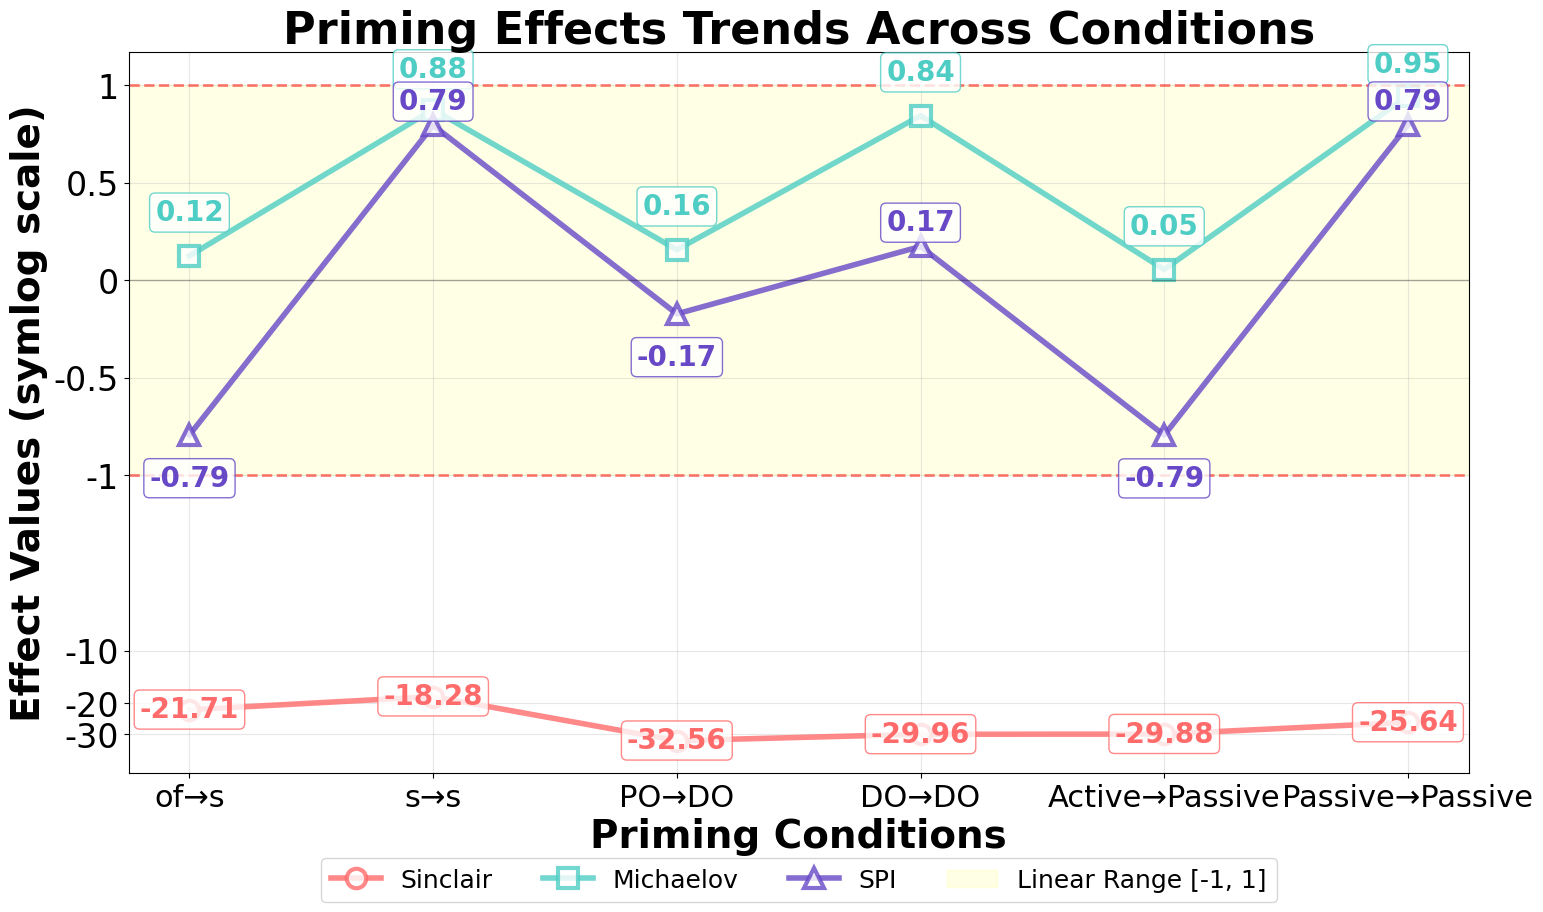

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
#save data if don't want run it again
data = {
    'Method': ['Sinclair', 'Michaelov', 'SPI'],
    'of_prime_s_target': [-21.714, 0.1249, -0.7939],
    's_prime_s_target': [-18.276, 0.8751, 0.7939],
    'PO_prime_DO_target': [-32.5624, 0.1563, -0.173],
    'DO_prime_DO_target': [-29.9608, 0.8437, 0.173],
    'Active_prime_Passive_target': [-29.8798, 0.0545, -0.7948],
    'Passive_prime_Passive_target': [-25.6352, 0.9455, 0.7948]
    
}

df = pd.DataFrame(data)

def create_symlog_line_chart():
    fig, ax = plt.subplots(figsize=(16, 10))
    
    conditions = ['of→s', 's→s', 'PO→DO', 'DO→DO', 'Active→Passive', 'Passive→Passive']
    x = np.arange(len(conditions))
    
    sinclair_values = [df.iloc[0, i+1] for i in range(6)]
    michaelov_values = [df.iloc[1, i+1] for i in range(6)]
    spi_values = [df.iloc[2, i+1] for i in range(6)]
    
    line1 = ax.plot(x, sinclair_values, marker='o', linewidth=4, markersize=14, 
                    label='Sinclair', color='#FF6B6B', alpha=0.8, markerfacecolor='white', 
                    markeredgewidth=3, markeredgecolor='#FF6B6B')
    
    line2 = ax.plot(x, michaelov_values, marker='s', linewidth=4, markersize=14, 
                    label='Michaelov', color='#4ECDC4', alpha=0.8, markerfacecolor='white',
                    markeredgewidth=3, markeredgecolor='#4ECDC4')
    
    line3 = ax.plot(x, spi_values, marker='^', linewidth=4, markersize=14, 
                    label='SPI', color='#6748c7', alpha=0.8, markerfacecolor='white',
                    markeredgewidth=3, markeredgecolor='#6748c7')
    
    ax.set_yscale('symlog', linthresh=1)
    
    yticks = [-30, -20, -10, -1, -0.5, 0, 0.5, 1, 2, 5]
    ax.set_yticks(yticks)
    ax.set_yticklabels([str(y) for y in yticks], fontsize=24)
    
    ax.grid(True, alpha=0.3)
    ax.axhspan(-1, 1, alpha=0.1, color='yellow', label='Linear Range [-1, 1]')
    
    ax.axhline(y=0, color='black', linestyle='-', alpha=0.3, linewidth=1)
    ax.axhline(y=1, color='red', linestyle='--', alpha=0.5, linewidth=2)
    ax.axhline(y=-1, color='red', linestyle='--', alpha=0.5, linewidth=2)
    
    ax.set_xlabel('Priming Conditions', fontsize=28, fontweight='bold')
    ax.set_ylabel('Effect Values (symlog scale)', fontsize=28, fontweight='bold')
    ax.set_title('Priming Effects Trends Across Conditions', fontsize=32, fontweight='bold')
    
    ax.set_xticks(x)
    ax.set_xticklabels(conditions, fontsize=22)
    
    def add_value_labels(x_pos, values, color, offset_y=0):
        for i, value in enumerate(values):
            if abs(value) < 2:
                va = 'bottom' if value >= 0 else 'top'
                y_offset = 0.1 if value >= 0 else -0.1
            else:
                va = 'center'
                y_offset = 0
                
            ax.text(x_pos[i], value + y_offset + offset_y,
                   f'{value:.2f}', ha='center', va=va,
                   fontsize=20, fontweight='bold', color=color,
                   bbox=dict(boxstyle="round,pad=0.2", facecolor='white', alpha=0.8, edgecolor=color))
    
    add_value_labels(x, sinclair_values, '#FF6B6B', offset_y=0.05)
    add_value_labels(x, michaelov_values, '#4ECDC4', offset_y=0.05)
    add_value_labels(x, spi_values, '#6748c7', offset_y=-0.05)
    
    ax.legend(fontsize=18, loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=4)
    
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.2) 
    return fig

if __name__ == "__main__":
    plt.rcParams.update({
        'font.size': 24,
        'axes.titlesize': 30,
        'axes.labelsize': 24,
        'xtick.labelsize': 24,
        'ytick.labelsize': 24,
        'legend.fontsize': 24,
        'figure.titlesize': 32
    })
    
    fig1 = create_symlog_line_chart()
    
    plt.show()

    fig1.savefig('symlog_line_chart.png', dpi=300, bbox_inches='tight')